# GraphRAG-NK — RQ1–RQ6 Analysis
*Implements the refined research questions from `REFINED_RQS.md` (FSE paper).*

**Layered claims** (per the refinement doc): descriptive (RQ1–RQ3) → comparative (RQ6) → critical (RQ4, RQ5). The critical layer is the paper's contribution; the descriptive layer is scaffolding.

**Design invariants honoured throughout:**
- Signals are never collapsed — every query counts Signals and/or distinct units explicitly.
- Headline counts use `status='active'` signals; `candidate` rules are reported separately, never silently merged (MARKER_REVIEW §3.5 convention).
- Non-NK contrastive signals (boosters M-6, `-free` privative) are excluded from every NK-positive definition — they exist only for RQ5 mixed-stance contrast.
- All queries exclude sandbox nodes (`coalesce(x.sandbox,false)=false`) so the Cypher-course data can coexist with real data.
- Rates are normalised per 1k TextUnits (RQ1 operationalisation: repos differ by orders of magnitude).

**Prerequisites:** populated Neo4j (full pipeline run; `--enrich` for RQ6 threading), and:
`pip install neo4j pandas matplotlib scikit-learn scipy pyyaml`


In [1]:
# ── Configuration & connections ──────────────────────────────────────────────
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from neo4j import GraphDatabase

import sys
sys.path.insert(0, str(Path.cwd().parent))   # repo root, for settings
from settings import settings

driver = GraphDatabase.driver(
    settings.neo4j_uri, auth=(settings.neo4j_user, settings.neo4j_password)
)

# ── The sandbox guard, explained ─────────────────────────────────────────────
# learn/00_seed_sandbox.cypher (the Cypher course dataset) tags EVERY node it
# creates with `sandbox: true` — including TextUnit and Signal nodes. Its toy
# sentences carry real NK markers ("I'm not sure why this crashes..."), so if
# that seed was installed into THIS database (the seed's install option B),
# those signals would silently pollute every count below. The production
# pipeline never writes `sandbox`, so the property exists only if you seeded.
#
# But referencing a property key that isn't registered in the store makes
# Neo4j 5.x emit `01N52 property key does not exist` on every query — noise
# that trains you to ignore warnings. So we resolve the guard ONCE here:
# if no `sandbox` key exists in the DB, the predicate is omitted entirely.
#
# NOT done: driver-level notifications_disabled_classifications=["UNRECOGNIZED"].
# That would silence 01N52 in one line, but the same class also reports
# genuine property-name TYPOS (u.parnet_type → silently null). Keeping that
# channel open is worth more than the convenience.
with driver.session() as _s:
    _prop_keys = {r[0] for r in _s.run("CALL db.propertyKeys()")}
SANDBOX_KEY_EXISTS = "sandbox" in _prop_keys

def q(cypher: str, **params) -> pd.DataFrame:
    """
    Run a Cypher query, return a DataFrame. All analysis goes through here.

    Queries write `@sandbox(u)` where they need the sandbox-exclusion guard;
    it expands to `coalesce(u.sandbox, false) = false` when sandbox data is
    present, or to `true` (a no-op the planner drops) when it isn't.
    """
    cypher = re.sub(
        r"@sandbox\((\w+)\)",
        lambda m: (f"coalesce({m.group(1)}.sandbox, false) = false"
                   if SANDBOX_KEY_EXISTS else "true"),
        cypher,
    )
    with driver.session() as session:
        return pd.DataFrame([r.data() for r in session.run(cypher, **params)])

pd.set_option("display.max_rows", 120)
plt.rcParams["figure.figsize"] = (10, 5)
print("Connected to", settings.neo4j_uri)
print(f"sandbox key present in DB: {SANDBOX_KEY_EXISTS} → guard "
      f"{'ACTIVE (course data may be present — it will be excluded)' if SANDBOX_KEY_EXISTS else 'inert (no sandbox data; predicate omitted)'}")

Connected to bolt://localhost:7687
sandbox key present in DB: False → guard inert (no sandbox data; predicate omitted)


In [2]:
# ── Rule metadata, loaded from the SAME YAML files the annotators load ───────
# Single source of truth: if the pattern files change, this notebook follows.
ROOT = Path.cwd().parent
V = settings.pattern_set_version

morpho_yaml = yaml.safe_load((ROOT / "patterns" / f"morpho_syntactic_v{V}.yml").read_text())
lex_yaml    = yaml.safe_load((ROOT / "lexicons" / f"en_core_v{V}.yml").read_text())
wf_yaml     = yaml.safe_load((ROOT / "patterns" / f"word_formation_v{V}.yml").read_text())

# RQ2: scoped (DependencyMatcher) vs cue-only (Matcher) morpho rules.
SCOPED_RULES = [p["id"] for p in morpho_yaml["patterns"] if p.get("type") == "DependencyMatcher"]

# Non-NK contrastive subcategories — NEVER counted as NK evidence.
# Boosters (M-6, Hyland certainty pole) + -free privative; both are
# polarity: certainty in their source files, so this is extracted, not hardcoded.
NON_NK_SUBCATS = sorted(
    {e.get("subcategory") for e in lex_yaml["entries"] if e.get("polarity") == "certainty"} |
    {s.get("subcategory") for s in wf_yaml.get("suffixes", []) if s.get("polarity") == "certainty"}
)

# RQ1: SE-native lexical subcategories (absent from the source taxonomies).
SE_NATIVE_LEX = ["repro_gap", "opacity", "spec_gap", "doc_gap",
                 "code_comment_marker", "non_deterministic_behaviour"]

# RQ3: SE-native vs canonical rhetorical subtypes.
SE_NATIVE_RHET = ["opacity", "hidden_extent", "obscurity"]

print(f"pattern_set_version = {V}")
print(f"Scoped rules ({len(SCOPED_RULES)}):", SCOPED_RULES)
print("Non-NK subcats:", NON_NK_SUBCATS)

pattern_set_version = 0.2
Scoped rules (5): ['morph.epi.neg_cognition', 'morph.epi.neg_cognition_modal', 'morph.hedge.shield_think', 'morph.neg.scoped_epistemic', 'morph.tense.past_nk_notyet']
Non-NK subcats: ['booster', 'privative_certainty']


## 0 · Corpus overview & sanity checks
Before any RQ: confirm the graph looks like a corpus worth analysing. A silent
annotator layer, missing verdicts, or leftover `quotation` units would corrupt
every downstream number — cheaper to fail loudly here.

In [3]:
# Node counts per label (sandbox excluded)
q("""
MATCH (n) WHERE @sandbox(n)
RETURN labels(n)[0] AS label, count(*) AS n ORDER BY n DESC
""")

,label,n
0,Signal,4317
1,TextUnit,2463
2,ClassifierVerdict,2358
3,Commit,2014
4,PullRequest,124
5,Actor,93
6,Issue,3
7,Repository,1
8,RhetoricalFigure,1


In [4]:
# Signals per layer × status. Every rule layer must be non-zero; the candidate
# column shows how much evidence is excluded from headline numbers.
df = q("""
MATCH (s:Signal) RETURN s.layer AS layer, s.status AS status, count(*) AS n
""")
layer_status = df.pivot_table(index="layer", columns="status", values="n", fill_value=0)
silent = {"lexical", "morpho_syntactic", "word_formation", "rhetorical"} - set(layer_status.index)
if silent:
    print(f"⚠️ SILENT LAYERS (no signals at all): {silent} — check annotator startup logs!")
layer_status

⚠️ SILENT LAYERS (no signals at all): {'lexical'} — check annotator startup logs!


status,active,candidate
layer,,
classifier,2358.0,0.0
morpho_syntactic,810.0,971.0
rhetorical,9.0,0.0
word_formation,149.0,20.0


In [5]:
# Rule-version mix: if 0.1 and 0.2 signals coexist (ablation runs), analyses
# must filter by rule_version or the numbers mix pattern sets.
df = q("MATCH (s:Signal) RETURN s.rule_version AS rule_version, count(*) AS n")
if len(df) > 1:
    print("⚠️ MULTIPLE rule versions in the graph — add `AND s.rule_version = $v` to every query below, or results mix pattern sets!")
df

⚠️ MULTIPLE rule versions in the graph — add `AND s.rule_version = $v` to every query below, or results mix pattern sets!


,rule_version,n
0,0.2,1959
1,roberta-non-knowledge-v8-base,2358


In [6]:
# RQ6 methodological control: quotation segments must not exist as TextUnits
# (excluded at extraction so quoted text cannot double-count a prior author's NK).
df = q("MATCH (u:TextUnit {role: 'quotation'}) RETURN count(u) AS n")
assert int(df.iloc[0, 0]) == 0, "quotation TextUnits found — RQ6 exclusion control violated!"
print("OK: no quotation TextUnits (RQ6 control holds).")

# Total units + arena split — reused for normalisation everywhere below.
# TextUnit.parent_type is stored on the node (issue|pull_request|commit|email),
# so arena is a simple CASE, no traversal.
totals = q("""
MATCH (u:TextUnit) WHERE @sandbox(u)
RETURN CASE WHEN u.parent_type = 'email' THEN 'mailing_list' ELSE 'github' END AS arena,
       count(*) AS units
""").set_index("arena")["units"]
TOTAL_UNITS = int(totals.sum())
ARENA_UNITS = totals.to_dict()
print(f"TextUnits: {TOTAL_UNITS} total — {ARENA_UNITS}")

OK: no quotation TextUnits (RQ6 control holds).
TextUnits: 2463 total — {'github': 2463}


---
## RQ1 · Lexical-denotative profile
**Question.** Which lexical NK markers occur, at what relative frequency, with what
SE-specific realisations absent from the source taxonomies?

**Operationalisation.** `layer='lexical'` counts by category/subcategory, rate per
1k TextUnits, SE-native subcategories reported separately. Reliability questions
belong to RQ5, not here (that split is the refinement).

In [7]:
# RQ1.1 — Inventory: counts + rate per 1k units, split active/candidate
rq1 = q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal {layer: 'lexical'})
WHERE @sandbox(u)
  AND NOT coalesce(s.subcategory, '') IN $non_nk
RETURN s.category AS category, s.subcategory AS subcategory, s.status AS status,
       count(*) AS signals, count(DISTINCT u) AS units
ORDER BY signals DESC
""", non_nk=NON_NK_SUBCATS)
rq1["rate_per_1k_units"] = (1000 * rq1["units"] / TOTAL_UNITS).round(2)
rq1["se_native"] = rq1["subcategory"].isin(SE_NATIVE_LEX)

print("── Headline (active) ──")
display(rq1[rq1.status == "active"].drop(columns="status"))
print("── Candidate (report separately; excluded from headline stats) ──")
display(rq1[rq1.status == "candidate"].drop(columns="status"))

KeyError: 'units'

In [ ]:
# RQ1.2 — THE headline number: the SE-native fraction of lexical NK
active = rq1[rq1.status == "active"]
se_frac_signals = active.loc[active.se_native, "signals"].sum() / active["signals"].sum()
print(f"SE-native fraction of active lexical NK signals: {se_frac_signals:.1%}")
print("(subcategories that exist in NO source taxonomy — the inventory contribution)")

In [ ]:
# RQ1.3 — Top-25 individual markers (rule level), for the paper's frequency table
rq1_rules = q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal {layer: 'lexical', status: 'active'})
WHERE @sandbox(u)
  AND NOT coalesce(s.subcategory, '') IN $non_nk
RETURN s.rule_id AS rule_id, s.subcategory AS subcategory,
       count(*) AS n, count(DISTINCT u) AS units
ORDER BY n DESC LIMIT 25
""", non_nk=NON_NK_SUBCATS)
rq1_rules["rate_per_1k"] = (1000 * rq1_rules["units"] / TOTAL_UNITS).round(2)

ax = rq1_rules.set_index("rule_id")["rate_per_1k"].plot.barh(figsize=(9, 8))
ax.invert_yaxis(); ax.set_xlabel("marker-bearing units per 1k TextUnits")
ax.set_title("RQ1: top lexical NK markers (active)")
plt.tight_layout(); plt.show()
rq1_rules

In [ ]:
# RQ1.4 — Per-source normalised rates. TextUnit has no repo property, so
# attribution traverses: (Repository|MailingList)-[:CONTAINS]->(artefact)-[:HAS_TEXT]->(u).
rq1_repo = q("""
MATCH (c)-[:CONTAINS]->(p)-[:HAS_TEXT]->(u:TextUnit)
WHERE (c:Repository OR c:MailingList) AND @sandbox(u)
WITH coalesce(c.full_name, c.name) AS source, u
OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(s:Signal {layer: 'lexical', status: 'active'})
WHERE NOT coalesce(s.subcategory, '') IN $non_nk
RETURN source, count(DISTINCT u) AS units,
       count(DISTINCT CASE WHEN s IS NOT NULL THEN u END) AS lexical_units
ORDER BY units DESC
""", non_nk=NON_NK_SUBCATS)
rq1_repo["rate_per_1k"] = (1000 * rq1_repo["lexical_units"] / rq1_repo["units"]).round(1)
rq1_repo

---
## RQ2 · Morpho-syntactic encoding & the **cue-vs-scope gap**
**Question.** Distribution across negation / modality / hedging / evidentiality /
tense / syntactic patterns — and what share of NK is only detectable via **scoped**
(DependencyMatcher) rules rather than bare token matches?

**Operationalisation.** Category distribution with the v0.2 corrections kept visible
(epistemic vs `underspecified` modality; `scoped_epistemic` vs `bare_negation` —
never summed); then the diagnostic contrast on classifier-positive units:
scoped-only / cue-only / both / neither. The **scoped-only share** is the direct
quantification of "unknown false negatives from keyword lists".

In [8]:
# RQ2.1 — Category × subcategory distribution, corrections visible
rq2 = q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal {layer: 'morpho_syntactic'})
WHERE @sandbox(u)
RETURN s.category AS category, s.subcategory AS subcategory, s.status AS status,
       count(*) AS signals, count(DISTINCT u) AS units,
       round(avg(s.weight), 2) AS avg_weight
ORDER BY category, signals DESC
""")
rq2["rate_per_1k"] = (1000 * rq2["units"] / TOTAL_UNITS).round(2)
rq2

,category,subcategory,status,signals,units,avg_weight,rate_per_1k
0,epistemic_verb,not_knowing,active,15,15,1.00,6.09
1,evidential,inferential,active,37,34,0.74,13.80
2,hedging,plausibility_shield,active,27,26,0.80,10.56
3,hedging,adverbial,active,20,19,0.70,7.71
4,hedging,attribution_shield,active,3,3,0.85,1.22
5,hedging,approximator,active,1,1,0.50,0.41
6,modality,underspecified,candidate,187,145,0.20,58.87
7,modality,epistemic_prediction,candidate,163,118,0.50,47.91
8,modality,deontic,active,101,93,0.40,37.76
9,modality,epistemic,active,33,30,0.79,12.18


In [9]:
# RQ2.2 — The families new in v0.2 (epistemic_verb, evidential, shields),
# reported separately per the refinement note.
rq2[rq2.category.isin(["epistemic_verb", "evidential"]) |
    rq2.subcategory.isin(["plausibility_shield", "attribution_shield"])]

,category,subcategory,status,signals,units,avg_weight,rate_per_1k
0,epistemic_verb,not_knowing,active,15,15,1.00,6.09
1,evidential,inferential,active,37,34,0.74,13.80
2,hedging,plausibility_shield,active,27,26,0.80,10.56
4,hedging,attribution_shield,active,3,3,0.85,1.22


In [10]:
# RQ2.3 — THE cue-vs-scope contingency on classifier-positive units.
rq2_gap = q("""
MATCH (u:TextUnit)-[:CLASSIFIED_AS]->(v:ClassifierVerdict)
WHERE v.label = 1 AND @sandbox(u)
OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(s:Signal {layer: 'morpho_syntactic', status: 'active'})
WITH u, collect(DISTINCT s.rule_id) AS rules
WITH u,
     any(r IN rules WHERE r IN $scoped)                        AS has_scoped,
     any(r IN rules WHERE NOT r IN $scoped AND r IS NOT NULL)  AS has_cue
RETURN has_scoped, has_cue, count(*) AS units
""", scoped=SCOPED_RULES)

pivot = rq2_gap.pivot_table(index="has_scoped", columns="has_cue",
                             values="units", fill_value=0)
total_pos = int(pivot.values.sum())
def cell(i, c):
    try: return int(pivot.loc[i, c])
    except KeyError: return 0
scoped_only = cell(True, False)
print(f"Classifier-positive units: {total_pos}")
if total_pos:
    print(f"SCOPED-ONLY morpho evidence: {scoped_only} ({scoped_only/total_pos:.1%})")
    print("→ NK invisible to any keyword list: the empirical justification for the")
    print("  scope-aware v0.2 design, and RQ2's headline contribution.")
pivot

Classifier-positive units: 144
SCOPED-ONLY morpho evidence: 7 (4.9%)
→ NK invisible to any keyword list: the empirical justification for the
  scope-aware v0.2 design, and RQ2's headline contribution.


has_cue,False,True
has_scoped,,
False,37.0,73.0
True,7.0,27.0


In [ ]:
# RQ2.4 — Which scoped constructions do the work? (name them in the paper)
q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal)
WHERE s.rule_id IN $scoped AND @sandbox(u)
RETURN s.rule_id AS rule_id, count(*) AS signals, count(DISTINCT u) AS units,
       collect(DISTINCT s.surface_form)[..5] AS sample_surface_forms
ORDER BY signals DESC
""", scoped=SCOPED_RULES)

---
## RQ3 · Rhetorical figures: SE-native vs canonical metaphors
**Question.** Which metaphor/comparison/personification families occur, and do SE
communities recruit domain-specific NK metaphors (black box, rabbit hole, can of
worms) at rates comparable to the canonical ignorance metaphors (blind spot,
knowledge gap, uncharted territory) from Simmerling & Janich (2015)?

**Operationalisation.** `layer='rhetorical'` counts by family/subtype; the
**SE-native : canonical ratio**; per-arena density (testable prediction: mailing
lists, being discursive, show more rhetorical NK than terse issue trackers).

In [11]:
# RQ3.1 — Family × subtype inventory
rq3 = q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal {layer: 'rhetorical'})
WHERE @sandbox(u)
RETURN s.category AS family, s.subcategory AS subtype, s.status AS status,
       count(*) AS signals, count(DISTINCT u) AS units
ORDER BY signals DESC
""")
rq3["rate_per_1k"] = (1000 * rq3["units"] / TOTAL_UNITS).round(2)
rq3["se_native"] = rq3["subtype"].isin(SE_NATIVE_RHET)
rq3

,family,subtype,status,signals,units,rate_per_1k,se_native
0,comparison,approximator,active,9,9,3.65,False


In [ ]:
# RQ3.2 — SE-native : canonical ratio.
# NOTE: several SE-native figures ship as status='candidate' (pending
# calibration), so the honest comparison is shown BOTH ways.
for status_filter, label in [(["active"], "active only"),
                              (["active", "candidate"], "active+candidate")]:
    sub = rq3[rq3.status.isin(status_filter)]
    se  = sub.loc[sub.se_native, "signals"].sum()
    can = sub.loc[~sub.se_native, "signals"].sum()
    ratio = f"{se/can:.2f}" if can else "n/a"
    print(f"{label:18s}: SE-native={se:5d}  canonical={can:5d}  ratio={ratio}")

In [ ]:
# RQ3.3 — Rhetorical density per arena (tests the register prediction)
rq3_arena = q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal {layer: 'rhetorical'})
WHERE @sandbox(u)
RETURN CASE WHEN u.parent_type = 'email' THEN 'mailing_list' ELSE 'github' END AS arena,
       count(*) AS signals, count(DISTINCT u) AS units
""")
rq3_arena["rate_per_1k"] = rq3_arena.apply(
    lambda r: round(1000 * r["units"] / ARENA_UNITS.get(r["arena"], 1), 2), axis=1)
print("Prediction: mailing_list rate > github rate (discursive register)")
rq3_arena

---
## RQ4 · Where the borrowed taxonomies fail *(primary theoretical contribution)*
**Question.** Clustering units by signal co-occurrence and mapping clusters post-hoc
onto Roberts / Smithson / Gross / Wehling: (a) which categories are populated,
(b) which SE NK phenomena fit **no** category (the residual), (c) which categories
receive ~zero SE instances (over-fit to non-SE domains)?

**Deliverables (falsifiable form):** a **coverage table** + a **residual set** —
"the taxonomy fits well" is a possible finding.

**Workflow.** (1) build the unit × signal-category vector → (2) cluster →
(3) export exemplars per cluster → (4) *human step:* audit exemplars, assign
taxonomy labels in `TAXONOMY_MAP` → (5) re-run the coverage/residual cells.
The mapping is deliberately manual — post-hoc labels are a qualitative judgement,
per the framework's design (taxonomic labels are post-hoc, never baked into rules).

In [41]:
# RQ4.1 — Unit × signal-category feature matrix.
# Features are layer.category (not subcategory — keeps dimensionality sane);
# only NK-relevant active signals (non-NK boosters excluded); only units with
# at least one signal OR classifier-positive (all-zero rows are uninformative).
rq4_long = q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal)
OPTIONAL MATCH (u)-[:CLASSIFIED_AS]->(v:ClassifierVerdict)
WITH u, s, v
WHERE v.label = 1 
   AND (
      s.layer <> 'classifier' 
      AND s.status = 'active'
      AND NOT coalesce(s.subcategory, '') IN $non_nk
   )
RETURN u.id AS unit, s.layer + '.' + s.category AS feature, count(*) AS n
""", non_nk=NON_NK_SUBCATS)

X = rq4_long.pivot_table(index="unit", columns="feature", values="n", fill_value=0)
# log1p: cluster on presence/strength, not raw counts (long units dominate otherwise)
X_log = np.log1p(X)
print(f"Feature matrix: {X.shape[0]} units × {X.shape[1]} features")
X.sum().sort_values(ascending=False)

Feature matrix: 109 units × 8 features


feature
morpho_syntactic.syntactic_pattern    140.0
morpho_syntactic.modality              34.0
morpho_syntactic.hedging               29.0
morpho_syntactic.epistemic_verb        15.0
morpho_syntactic.evidential            15.0
word_formation.affix_negation          13.0
rhetorical.comparison                   8.0
morpho_syntactic.negation               4.0
dtype: float64

In [38]:
X_log

feature,classifier.roberta_binary,morpho_syntactic.epistemic_verb,morpho_syntactic.evidential,morpho_syntactic.hedging,morpho_syntactic.modality,morpho_syntactic.negation,morpho_syntactic.syntactic_pattern,morpho_syntactic.tense,rhetorical.comparison,word_formation.affix_negation
unit,,,,,,,,,,
commit:00953990baf2692969df8839410f309d31f5632d:commit_message,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.0,0.000000,0.000000
commit:009df4251250951339bac9ab7cddb0a1823eee8f:commit_message,0.693147,0.000000,1.098612,0.000000,1.386294,0.000000,1.098612,0.0,0.000000,0.000000
commit:00f9b3e7576df88418f4aac45c8643da846276f1:commit_message,0.693147,0.693147,0.000000,0.000000,0.693147,1.098612,0.693147,0.0,0.000000,0.693147
commit:01048626a0d615a18c9936a128a1cb46b53e6036:commit_message,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
commit:0147ccde42027e0d76a6eb7b675b07af26f0c5e3:commit_message,0.000000,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
pr:OpenVoxProject/ezbake:99:comment_body:4,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,1.945910,0.0,0.000000,0.000000
pr:OpenVoxProject/ezbake:99:comment_body:5,0.693147,0.000000,0.000000,0.000000,0.000000,1.098612,0.693147,0.0,0.000000,0.000000
pr:OpenVoxProject/ezbake:99:comment_body:6,0.693147,0.000000,0.000000,0.693147,0.693147,0.000000,1.386294,0.0,0.000000,0.000000


In [42]:
# RQ4.2 — Cluster. K chosen by silhouette over a small grid; KMeans on the
# log counts is deliberately simple/reproducible — the clusters only need to be
# good enough to organise a qualitative audit, not to be the contribution.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X_log)
scores = {}
for k in range(3, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    scores[k] = silhouette_score(Xs, km.labels_, sample_size=min(5000, len(Xs)),
                                  random_state=42)
best_k = max(scores, key=scores.get)
print("silhouette by k:", {k: round(v, 3) for k, v in scores.items()})
print(f"→ using k = {best_k}")

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xs)
clusters = pd.Series(km.labels_, index=X.index, name="cluster")
clusters.value_counts().sort_index()

silhouette by k: {3: 0.28, 4: 0.355, 5: 0.395, 6: 0.462, 7: 0.512, 8: 0.533, 9: 0.548, 10: 0.561}
→ using k = 10


cluster
0    21
1     2
2    24
3    13
4     6
5     4
6     8
7    18
8     4
9     9
Name: count, dtype: int64

In [16]:
Xs

array([[-0.17407766, -0.26376699, -0.29561189, ..., -0.11589023,
        -0.13403012, -0.55873599],
       [-0.17407766,  5.6993618 , -0.29561189, ..., -0.11589023,
        -0.13403012, -0.55873599],
       [ 5.74456265, -0.26376699, -0.29561189, ..., -0.11589023,
        -0.13403012,  1.49014626],
       ...,
       [-0.17407766, -0.26376699,  2.87767326, ..., -0.11589023,
        -0.13403012, -0.55873599],
       [-0.17407766,  3.49854839, -0.29561189, ..., -0.11589023,
         7.46100976, -0.55873599],
       [-0.17407766, -0.26376699, -0.29561189, ..., -0.11589023,
        -0.13403012, -0.55873599]], shape=(510, 9))

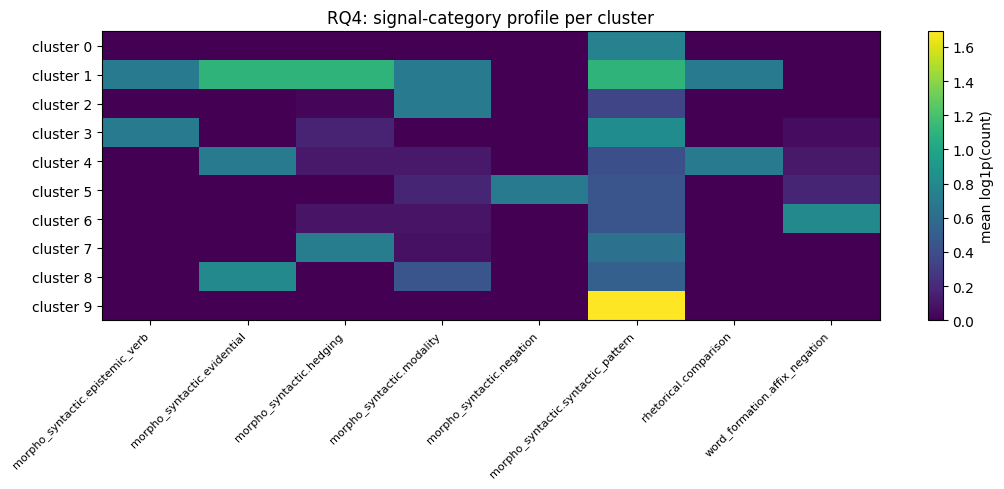

In [43]:
# RQ4.3 — Cluster profiles: mean signal-category vector per cluster
profile = X_log.groupby(clusters).mean()
fig, ax = plt.subplots(figsize=(11, max(3, 0.5 * best_k)))
im = ax.imshow(profile.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(profile.columns)))
ax.set_xticklabels(profile.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(profile.index)))
ax.set_yticklabels([f"cluster {c}" for c in profile.index])
plt.colorbar(im, label="mean log1p(count)")
ax.set_title("RQ4: signal-category profile per cluster")
plt.tight_layout(); plt.show()

In [ ]:
# RQ4.4 — Export exemplars per cluster for the qualitative audit.
# 10 random + the 5 highest-signal units per cluster → CSV for hand inspection.
N_RANDOM, N_TOP = 10, 5
rows = []
rng = np.random.default_rng(42)
sig_totals = X.sum(axis=1)
for c in sorted(clusters.unique()):
    members = clusters[clusters == c].index
    top = sig_totals.loc[members].nlargest(N_TOP).index.tolist()
    rest = [u for u in members if u not in top]
    rand = list(rng.choice(rest, size=min(N_RANDOM, len(rest)), replace=False)) if rest else []
    for uid in top + rand:
        rows.append({"cluster": c, "unit": uid, "kind": "top" if uid in top else "random"})
sample = pd.DataFrame(rows)

texts = q("""
UNWIND $ids AS uid MATCH (u:TextUnit {id: uid})
RETURN u.id AS unit, u.parent_type AS parent_type, left(u.text, 400) AS text
""", ids=sample["unit"].tolist())
exemplars = sample.merge(texts, on="unit")
out = Path("rq4_cluster_exemplars.csv")
exemplars.assign(roberts="", smithson="", gross_wehling="", notes="").to_csv(out, index=False)
print(f"→ {out} written ({len(exemplars)} exemplars). Audit it, then fill TAXONOMY_MAP below.")
exemplars.groupby("cluster").head(2)[["cluster", "kind", "parent_type", "text"]]

In [ ]:
# RQ4.5 — HUMAN STEP: after auditing the exemplar CSV, record each cluster's
# post-hoc taxonomy assignment here. "RESIDUAL" = fits no category (the paper's
# key evidence); None = not yet audited. Multiple labels allowed per cluster.
TAXONOMY_MAP: dict[int, dict] = {
    # 0: {"roberts": "known unknowns", "smithson": "uncertainty/vagueness", "notes": "..."},
    # 1: {"roberts": "RESIDUAL", "smithson": "RESIDUAL", "notes": "repro_gap units — no category fits"},
}

if not TAXONOMY_MAP:
    print("TAXONOMY_MAP is empty — fill it after the qualitative audit, then run RQ4.6.")

In [ ]:
# RQ4.6 — Coverage table + residual set (the falsifiable deliverables).
if TAXONOMY_MAP:
    cov = pd.DataFrame([
        {"cluster": c, "units": int((clusters == c).sum()), **labels}
        for c, labels in TAXONOMY_MAP.items()
    ])
    total_mapped = cov["units"].sum()
    residual_units = cov.loc[
        cov.apply(lambda r: "RESIDUAL" in {r.get("roberts"), r.get("smithson")}, axis=1), "units"
    ].sum()
    print(f"Residual (fits no borrowed category): {residual_units}/{total_mapped} "
          f"clustered units ({residual_units/total_mapped:.1%})")
    print("Categories receiving ~zero instances = rows absent from the map — list them")
    print("manually against the full Roberts/Smithson category inventories.")
    display(cov)
else:
    print("Run after filling TAXONOMY_MAP (RQ4.5).")

---
## RQ5 · Marker–classifier disagreement & per-rule reliability *(primary methodological contribution)*
**Question.** Partition units by (marker-positive) × (classifier-positive): what are
the disagreement cells made of? And what is each rule's precision on a hand-labelled
stratified sample — how many rules clear τ?

**Definitions.** marker-positive = ≥1 `active` non-classifier NK signal (non-NK
boosters excluded). classifier-positive = verdict `label=1`.

**Workflow.** 2×2 first → export disagreement samples + stratified per-rule samples
→ *human step:* label the CSVs → re-import → precision table + promotion
recommendations. **Note:** applying promotions to the graph is gated behind an
explicit flag and OFF by default — empirical calibration is deliberately deferred
(MARKER_REVIEW §3.5); this notebook computes the evidence, it does not act on it.

In [ ]:
# RQ5.1 — The 2×2 contingency
rq5 = q("""
MATCH (u:TextUnit) WHERE @sandbox(u)
OPTIONAL MATCH (u)-[:CLASSIFIED_AS]->(v:ClassifierVerdict)
WITH u, max(CASE WHEN v.label = 1 THEN 1 ELSE 0 END) AS clf
OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(s:Signal)
WHERE s.layer <> 'classifier' AND s.status = 'active'
  AND NOT coalesce(s.subcategory, '') IN $non_nk
WITH u, clf, count(s) > 0 AS marker
RETURN marker AS marker_positive, clf = 1 AS classifier_positive, count(*) AS units
""", non_nk=NON_NK_SUBCATS)
pivot5 = rq5.pivot_table(index="marker_positive", columns="classifier_positive",
                          values="units", fill_value=0)
n = pivot5.values.sum()
print(f"{n} units total. Disagreement cells are the analysis targets:")
print("  marker+/clf− → noisy markers OR classifier misses (RQ5a)")
print("  marker−/clf+ → constructional/implicit NK no rule catches — the")
print("                 'unknown false negatives' made countable (RQ5b)")
pivot5

In [ ]:
# RQ5.2 — Export disagreement samples for hand labelling
N_PER_CELL = 100

# NB Cypher subtlety: rand() must be attached in a SEPARATE `WITH` after the
# aggregation — placed alongside collect(), it becomes part of the grouping
# key (evaluated per row), which silently breaks the aggregation and can
# duplicate units in the sample.
mpos_cneg = q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal)
WHERE @sandbox(u) AND s.layer <> 'classifier'
  AND s.status = 'active' AND NOT coalesce(s.subcategory, '') IN $non_nk
  AND NOT EXISTS { MATCH (u)-[:CLASSIFIED_AS]->(v) WHERE v.label = 1 }
WITH u, collect(DISTINCT s.rule_id) AS rules
WITH u, rules, rand() AS r
ORDER BY r LIMIT $n
RETURN u.id AS unit, left(u.text, 400) AS text, rules
""", non_nk=NON_NK_SUBCATS, n=N_PER_CELL)

mneg_cpos = q("""
MATCH (u:TextUnit)-[:CLASSIFIED_AS]->(v:ClassifierVerdict)
WHERE v.label = 1 AND @sandbox(u)
  AND NOT EXISTS {
    MATCH (u)-[:HAS_SIGNAL]->(s:Signal)
    WHERE s.layer <> 'classifier' AND s.status = 'active'
      AND NOT coalesce(s.subcategory, '') IN $non_nk
  }
WITH u, max(v.confidence) AS conf
WITH u, conf, rand() AS r
ORDER BY r LIMIT $n
RETURN u.id AS unit, left(u.text, 400) AS text, conf
""", non_nk=NON_NK_SUBCATS, n=N_PER_CELL)

for df, name in [(mpos_cneg, "rq5_marker_pos_clf_neg.csv"),
                 (mneg_cpos, "rq5_marker_neg_clf_pos.csv")]:
    df.assign(is_genuine_nk="", error_type="", notes="").to_csv(name, index=False)
    print(f"→ {name} ({len(df)} rows) — label is_genuine_nk ∈ {{yes,no,ambiguous}}")

In [ ]:
# RQ5.3 — Stratified per-rule sample export (≈50–100 units per high-freq rule)
SAMPLE_PER_RULE, MIN_RULE_FREQ = 50, 100

top_rules = q("""
MATCH (s:Signal) WHERE s.layer <> 'classifier'
RETURN s.rule_id AS rule_id, count(*) AS n
ORDER BY n DESC
""")
eligible = top_rules[top_rules.n >= MIN_RULE_FREQ]["rule_id"].tolist()
print(f"{len(eligible)} rules with ≥{MIN_RULE_FREQ} signals → sampling {SAMPLE_PER_RULE} each")

frames = []
for rid in eligible:
    frames.append(q("""
    MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal {rule_id: $rid})
    WHERE @sandbox(u)
    WITH u, s, rand() AS r ORDER BY r LIMIT $n
    RETURN s.rule_id AS rule_id, u.id AS unit, s.surface_form AS surface_form,
           left(u.text, 400) AS text
    """, rid=rid, n=SAMPLE_PER_RULE))
strat = pd.concat(frames, ignore_index=True)
strat.assign(marks_genuine_nk="").to_csv("rq5_rule_precision_sample.csv", index=False)
print(f"→ rq5_rule_precision_sample.csv ({len(strat)} rows) — label marks_genuine_nk ∈ {{yes,no}}")

In [ ]:
# RQ5.4 — After labelling: per-rule precision + reliability table.
TAU = 0.70   # reliability threshold from REFINED_RQS / MARKER_REVIEW §3.5

labelled_path = Path("rq5_rule_precision_sample.csv")
lab = pd.read_csv(labelled_path)
lab = lab[lab["marks_genuine_nk"].isin(["yes", "no"])]
if lab.empty:
    print("No labels yet — fill marks_genuine_nk in the CSV, re-run this cell.")
else:
    rel = (lab.assign(correct=lab["marks_genuine_nk"] == "yes")
              .groupby("rule_id")
              .agg(labelled=("correct", "size"), precision=("correct", "mean"))
              .round(3).sort_values("precision"))
    rel["recommend"] = np.where(rel["precision"] >= TAU, "active", "candidate")
    print(f"Rules clearing τ={TAU}: {(rel.precision >= TAU).sum()}/{len(rel)}")
    display(rel)   # ← the paper's marker-reliability table

In [ ]:
# RQ5.5 — Marker RECALL estimate: fraction of a labelled random sample of
# classifier-positive units that carries ≥1 marker. (Uses the same
# rq5_marker_neg_clf_pos.csv labels: units confirmed genuine-NK there are
# marker recall FAILURES by construction; combine with the 2×2 for the estimate.)
mn = pd.read_csv("rq5_marker_neg_clf_pos.csv")
mn_labelled = mn[mn["is_genuine_nk"].isin(["yes", "no", "ambiguous"])]
if mn_labelled.empty:
    print("Label rq5_marker_neg_clf_pos.csv first.")
else:
    genuine_missed_frac = (mn_labelled["is_genuine_nk"] == "yes").mean()
    both      = int(pivot5.loc[True, True]) if True in pivot5.index else 0
    clf_only  = int(pivot5.loc[False, True]) if False in pivot5.index else 0
    est_missed = clf_only * genuine_missed_frac
    recall = both / (both + est_missed) if (both + est_missed) else float("nan")
    print(f"Of clf-positive/marker-negative sample: {genuine_missed_frac:.0%} genuine NK")
    print(f"→ estimated marker recall on classifier-positive NK: {recall:.1%}")

In [ ]:
# RQ5.6 — OPTIONAL, OFF BY DEFAULT: write promotion recommendations back to the
# graph (Signal.status per rule). Calibration is DEFERRED per MARKER_REVIEW §3.5;
# flip the flag only when the labelled sample is big enough to act on. The YAML
# files remain the source of truth for NEW runs — update their status fields too.
APPLY_PROMOTIONS = False

if APPLY_PROMOTIONS and "rel" in dir():
    for rid, row in rel.iterrows():
        q("""MATCH (s:Signal {rule_id: $rid}) SET s.status = $st""",
          rid=rid, st=row["recommend"])
    print("Applied. ⚠️ Also update the YAML status fields, or the next pipeline run reverts this.")
else:
    print("Not applied (APPLY_PROMOTIONS=False) — recommendations are reporting-only.")

---
## RQ6 · Cross-arena and cross-community NK profiles
**Question.** Do issue trackers and mailing lists differ in NK rate, layer mix, and
taxonomic profile — and do communities cluster by NK signature?

**Predictions to test** (stated in advance, per the refinement): mailing lists show
more hedging/rhetorical NK (discursive register); issue trackers more
`repro_gap`/`spec_gap` (task register). Quotation exclusion verified in §0.

In [ ]:
# RQ6.1 — NK rate per 1k units and layer mix, per arena
rq6 = q("""
MATCH (u:TextUnit) WHERE @sandbox(u)
WITH u, CASE WHEN u.parent_type = 'email' THEN 'mailing_list' ELSE 'github' END AS arena
OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(s:Signal)
WHERE s.layer <> 'classifier' AND s.status = 'active'
  AND NOT coalesce(s.subcategory, '') IN $non_nk
RETURN arena, s.layer AS layer, count(s) AS signals, count(DISTINCT u) AS units
""", non_nk=NON_NK_SUBCATS)

mix = (rq6.dropna(subset=["layer"])
          .pivot_table(index="arena", columns="layer", values="signals", fill_value=0))
mix_norm = mix.div(mix.sum(axis=1), axis=0).round(3)
print("Layer-mix vector per arena (row-normalised):")
display(mix_norm)
mix_norm.plot.bar(stacked=True, figsize=(7, 4), title="RQ6: NK layer mix by arena")
plt.ylabel("share of active NK signals"); plt.tight_layout(); plt.show()

In [ ]:
# RQ6.2 — Statistical test of the arena difference in layer mix (chi-square
# on the signal-count contingency; report effect size via Cramér's V, since with
# large n everything is 'significant').
from scipy.stats import chi2_contingency
if mix.shape[0] == 2 and mix.values.sum() > 0:
    chi2, p, dof, _ = chi2_contingency(mix.values)
    cramers_v = np.sqrt(chi2 / (mix.values.sum() * (min(mix.shape) - 1)))
    print(f"chi² = {chi2:.1f}, dof = {dof}, p = {p:.2e}, Cramér's V = {cramers_v:.3f}")
else:
    print("Need both arenas populated — is the Gmane corpus ingested?")

In [ ]:
# RQ6.3 — The two register predictions, tested directly
pred = q("""
MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal {status: 'active'})
WHERE @sandbox(u)
  AND (s.category = 'hedging' OR s.layer = 'rhetorical'
       OR s.subcategory IN ['repro_gap', 'spec_gap'])
WITH CASE WHEN u.parent_type = 'email' THEN 'mailing_list' ELSE 'github' END AS arena,
     CASE WHEN s.subcategory IN ['repro_gap', 'spec_gap'] THEN 'task_register'
          ELSE 'discursive_register' END AS marker_group,
     count(DISTINCT u) AS units
RETURN arena, marker_group, units
""")
pred["rate_per_1k"] = pred.apply(
    lambda r: round(1000 * r["units"] / ARENA_UNITS.get(r["arena"], 1), 2), axis=1)
print("Predicted: discursive higher in mailing_list; task_register higher in github")
pred.pivot_table(index="marker_group", columns="arena", values="rate_per_1k")

In [ ]:
# RQ6.4 — Community NK signatures: per-source layer-mix vectors, clustered.
# (Only meaningful with ≥4–5 sources; with fewer, just inspect the table.)
sig = q("""
MATCH (c)-[:CONTAINS]->(p)-[:HAS_TEXT]->(u:TextUnit)
WHERE (c:Repository OR c:MailingList) AND @sandbox(u)
WITH coalesce(c.full_name, c.name) AS source, u
MATCH (u)-[:HAS_SIGNAL]->(s:Signal {status: 'active'})
WHERE s.layer <> 'classifier' AND NOT coalesce(s.subcategory, '') IN $non_nk
RETURN source, s.layer + '.' + s.category AS feature, count(*) AS n
""", non_nk=NON_NK_SUBCATS)
sig_mat = sig.pivot_table(index="source", columns="feature", values="n", fill_value=0)
sig_norm = sig_mat.div(sig_mat.sum(axis=1), axis=0)
print(f"{len(sig_norm)} sources × {sig_norm.shape[1]} features")
if len(sig_norm) >= 4:
    from scipy.cluster.hierarchy import linkage, dendrogram
    fig, ax = plt.subplots(figsize=(9, 4))
    dendrogram(linkage(sig_norm.values, method="ward"),
               labels=sig_norm.index.tolist(), ax=ax)
    ax.set_title("RQ6: communities clustered by NK signature")
    plt.tight_layout(); plt.show()
sig_norm.round(3)

In [ ]:
# RQ6.5 — Thread-position analysis (mailing lists only, needs --enrich):
# does NK concentrate in thread openers or in replies?
rq6_thread = q("""
MATCH (e:EmailMessage)-[:HAS_TEXT]->(u:TextUnit)
WHERE @sandbox(u)
WITH e, u, EXISTS { MATCH (e)-[:REPLIES_TO]->() } AS is_reply
OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(s:Signal {status: 'active'})
WHERE s.layer <> 'classifier' AND NOT coalesce(s.subcategory, '') IN $non_nk
RETURN CASE WHEN is_reply THEN 'reply' ELSE 'thread_opener' END AS position,
       count(DISTINCT u) AS units,
       count(DISTINCT CASE WHEN s IS NOT NULL THEN u END) AS nk_units
""", non_nk=NON_NK_SUBCATS)
if rq6_thread.empty or rq6_thread["units"].sum() == 0:
    print("No email units — run the Gmane ingest + --enrich first.")
else:
    rq6_thread["nk_rate"] = (rq6_thread["nk_units"] / rq6_thread["units"]).round(3)
    display(rq6_thread)

---
## Wrap-up: paper artefact checklist
| RQ | artefact produced above | destination in paper |
|---|---|---|
| RQ1 | inventory tables (§1.1/1.3) + SE-native fraction (§1.2) | frequency table + one headline number |
| RQ2 | category table (§2.1) + cue-vs-scope 2×2 (§2.3) | scoped-only share = headline number |
| RQ3 | SE:canonical ratio (§3.2) + arena density (§3.3) | metaphor-portability finding |
| RQ4 | `rq4_cluster_exemplars.csv` → coverage table + residual (§4.6) | **core theoretical claim** |
| RQ5 | 2×2 (§5.1), 3 labelling CSVs, reliability table (§5.4), recall estimate (§5.5) | **core methodological claim** |
| RQ6 | layer-mix + χ²/Cramér's V (§6.1–2), predictions (§6.3), community dendrogram (§6.4) | cross-arena finding |

**Deliberately out of scope** (per REFINED_RQS.md): temporal evolution (next paper),
causal effect of NK on outcomes (needs identification strategy).

In [ ]:
driver.close()
print("Done.")